# UOI Games — Étude de marché & recommandation stratégique pour un premier jeu Triple A

**Contexte du projet.** UOI Games, un studio de jeu vidéo, envisage de développer son premier titre Triple A. Avant d'engager un développement long et coûteux, ce projet analyse les tendances du marché, identifie le segment de clientèle le plus pertinent, et formule une recommandation de concept argumentée par la donnée — sans calcul du coût de développement (hors périmètre de la mission).

**Ce notebook est une synthèse.** Il condense en un seul document le fil conducteur de 5 notebooks d'analyse détaillés (nettoyage des données, tendances & SWOT/PESTEL, segmentation, tests de corrélation sur un questionnaire terrain, recommandation finale). Le code ci-dessous est exécutable de bout en bout avec les données incluses dans le dossier `data/`.

**Méthode en un coup d'œil :**
1. Nettoyage et exploration de 3 jeux de données (catalogue de jeux, ventes historiques, ventes de consoles)
2. Recherche de marché externe (2024-2026) → tendances, SWOT, PESTEL
3. Segmentation chiffrée à partir du catalogue
4. Validation par questionnaire terrain (20 répondants) et tests de corrélation
5. Recommandation finale : segment, concept de jeu, écosystème, prévision de ventes


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, spearmanr

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 10


---
## 1. Données et méthode

Trois jeux de données sources ont été fournis par le studio :

| Fichier | Contenu | Période |
|---|---|---|
| Catalogue de jeux | 440 896 jeux : genres, plateformes, notes et engagement des joueurs | 2000-2020 |
| Ventes de jeux | 16 545 jeux ayant dépassé 100 000 ventes, par zone géographique | 1980-2020 |
| Ventes de consoles | Ventes cumulées de 20 consoles par constructeur | 1989-2020 |

Le catalogue complet (440 896 lignes, ~120 Mo une fois nettoyé) n'est pas inclus dans ce dépôt pour rester léger — les deux tableaux agrégés qui en sont tirés (`genre_plateforme_agg.csv`, `esrb_par_genre_agg.csv`) le sont, et suffisent à reproduire les graphiques de ce notebook. Le détail complet du nettoyage du catalogue est disponible dans le notebook `P10_Phase1_Nettoyage.ipynb`.


In [2]:
sales = pd.read_csv('data/sales_clean.csv', low_memory=False)
console = pd.read_csv('data/console_clean.csv')
genre_platform = pd.read_csv('data/genre_plateforme_agg.csv')
esrb_genre = pd.read_csv('data/esrb_par_genre_agg.csv', index_col=0)
survey = pd.read_csv('data/questionnaire_jeux_video.csv', encoding='utf-8-sig')
survey.columns = ['age','plateformes','genres','frequence','famille','depenses',
                   'licence','lootbox','facteur_essai','jeu_souhaite']

print(f'Ventes de jeux      : {len(sales):,} lignes'.replace(',', ' '))
print(f'Ventes de consoles  : {len(console)} lignes')
print(f'Réponses au sondage : {len(survey)} répondants')


Ventes de jeux      : 16 545 lignes
Ventes de consoles  : 20 lignes
Réponses au sondage : 20 répondants


---
## 2. Le marché aujourd'hui : ce que disent les données historiques

Les ventes historiques (1980-2020) confirment une hiérarchie de genres très stable : Action, Sport et Shooter dominent largement, cohérent avec les tendances observées sur le marché actuel (2025-2026 : Shooter, Action-Aventure et Sport restent les 3 genres les plus pratiqués mondialement — source Statista/Newzoo).


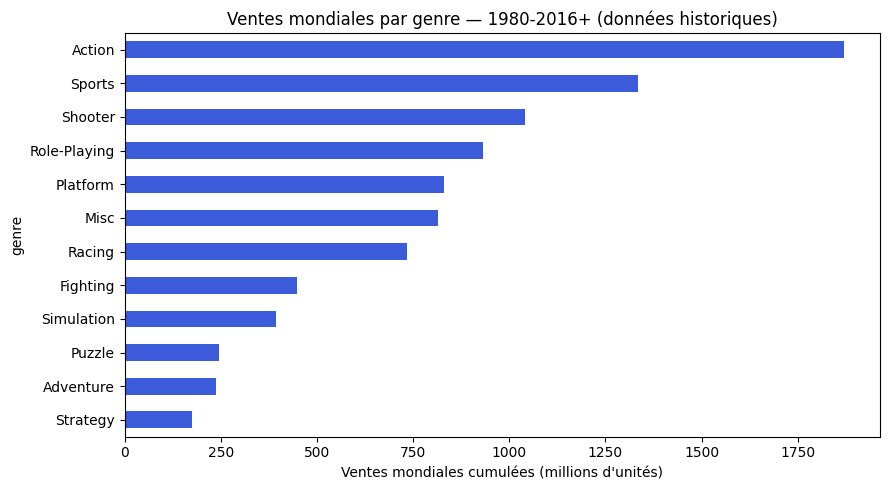

In [3]:
genre_sales = sales.groupby('genre')['global_sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots()
genre_sales.plot(kind='barh', ax=ax, color='#3B5BDB')
ax.invert_yaxis()
ax.set_xlabel("Ventes mondiales cumulées (millions d'unités)")
ax.set_title('Ventes mondiales par genre — 1980-2016+ (données historiques)')
plt.tight_layout()
plt.show()


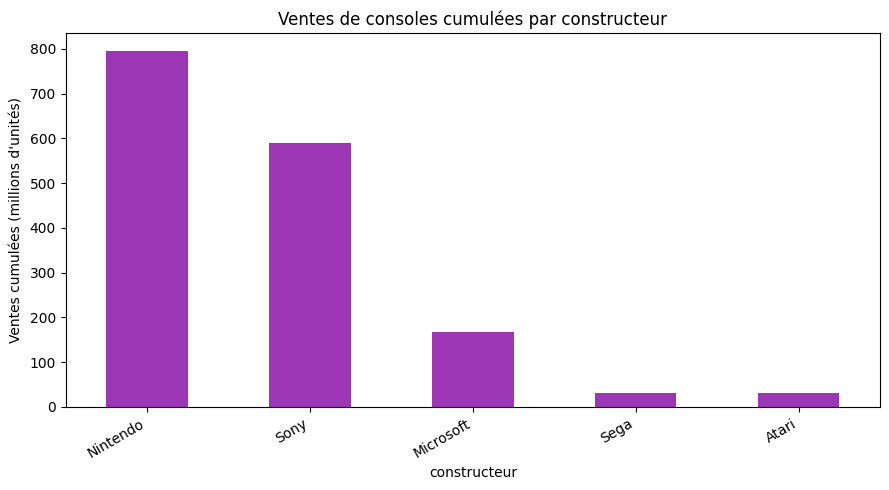

In [4]:
console_by_maker = console.groupby('constructeur')['ventes_millions'].sum().sort_values(ascending=False)

fig, ax = plt.subplots()
console_by_maker.plot(kind='bar', ax=ax, color='#9C36B5')
ax.set_ylabel("Ventes cumulées (millions d'unités)")
ax.set_title('Ventes de consoles cumulées par constructeur')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


---
## 3. Tendances 2025-2026, SWOT & PESTEL — synthèse

Une recherche de marché externe (Newzoo, ESA, SELL, BCG, 2025-2026) a complété les données historiques pour couvrir la période récente, absente des fichiers fournis.

**Tendances clés :**
- Marché mondial : 189-205 Md$, 3,6-3,7 Md joueurs ; marché français : 5,856 Md€ (+2,9%), joueur moyen **40 ans** (loin du cliché adolescent)
- Le marché récompense la **rétention** des joueurs plus que l'acquisition de nouveaux joueurs
- Convergence des plateformes (cloud gaming testé par 60% des joueurs), IA générative réduisant certains coûts de production de 30-40%
- Budgets Triple A en forte inflation (80-300 M$+) ; régulation européenne croissante des achats aléatoires ("loot box") avec le *Digital Fairness Act*

**SWOT (synthèse) :**

| | Positif | Négatif |
|---|---|---|
| **Interne** | Studio déjà actif dans le jeu vidéo ; marché français en croissance ; page blanche sur l'IP | Aucun track record Triple A ; budget/équipe probablement sous les standards du marché |
| **Externe** | Marché mondial en croissance ; gains de productivité via l'IA ; essor du cloud gaming | Budgets Triple A en forte inflation ; concurrence des blockbusters établis ; régulation des loot box |

**PESTEL (points saillants) :** Social — joueur moyen vieilli à 40 ans, quasi-parité hommes/femmes. Légal — encadrement européen des loot box à anticiper dès la conception du modèle économique. Technologique — IA générative et cloud gaming redéfinissent les coûts de production et de diffusion.

*(Détail complet : `P10_Phase2_Tendances_SWOT_PESTEL.ipynb`)*


---
## 4. Segmentation à partir du catalogue de jeux

Deux segments candidats ont été identifiés en croisant les genres, les plateformes et le profil d'âge légal (classification ESRB) du catalogue.


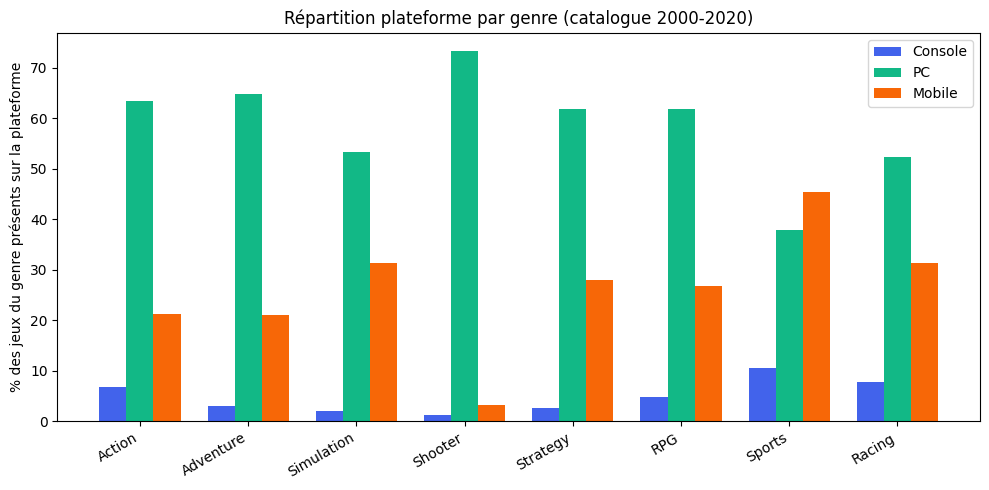

In [5]:
fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(genre_platform))
w = 0.25
ax.bar(x-w, genre_platform['pct_console'], width=w, label='Console', color='#4263EB')
ax.bar(x, genre_platform['pct_pc'], width=w, label='PC', color='#12B886')
ax.bar(x+w, genre_platform['pct_mobile'], width=w, label='Mobile', color='#F76707')
ax.set_xticks(x)
ax.set_xticklabels(genre_platform['genre'], rotation=30, ha='right')
ax.set_ylabel('% des jeux du genre présents sur la plateforme')
ax.set_title('Répartition plateforme par genre (catalogue 2000-2020)')
ax.legend()
plt.tight_layout()
plt.show()


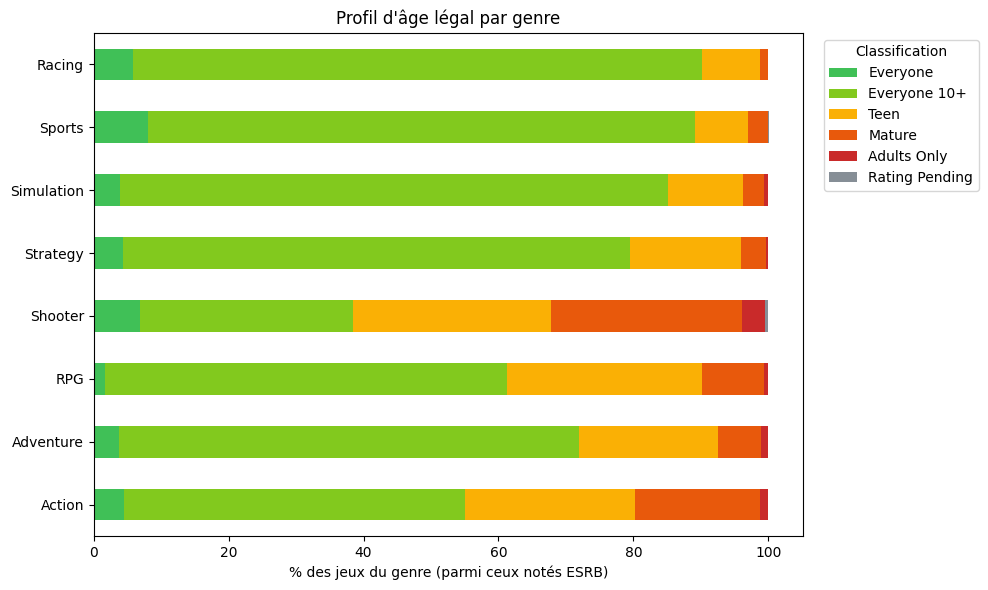

In [6]:
esrb_order = ['Everyone', 'Everyone 10+', 'Teen', 'Mature', 'Adults Only', 'Rating Pending']
fig, ax = plt.subplots(figsize=(10,6))
esrb_genre[esrb_order].plot(kind='barh', stacked=True, ax=ax,
    color=['#40C057','#82C91E','#FAB005','#E8590C','#C92A2A','#868E96'])
ax.set_xlabel('% des jeux du genre (parmi ceux notés ESRB)')
ax.set_title("Profil d'âge légal par genre")
ax.legend(title='Classification', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


**Deux segments candidats en ressortent :**
- **Segment A** — Action/RPG, classification Teen-Mature, console+PC : le segment le plus vaste en volume historique et le plus engagé (note et temps de jeu les plus élevés du catalogue), mais aussi le plus concurrentiel.
- **Segment B** — Sport/Simulation, classification Everyone-Everyone 10+, plutôt console : moins saturé, profil plus familial/multigénérationnel.

*(Détail complet, méthodologie et questionnaire : `P10_Phase3_Segmentation_Questionnaire.ipynb`)*


---
## 5. Validation terrain : tests de corrélation sur 20 réponses au questionnaire

Un questionnaire de 10 questions a été diffusé pour tester ces hypothèses avec de vraies données déclaratives. **Avertissement méthodologique :** avec n=20, les résultats ci-dessous sont des tendances indicatives, pas des preuves statistiques définitives.


In [7]:
A_GENRES = {'Action', 'RPG', 'Shooter'}
B_GENRES = {'Sport', 'Simulation', 'Stratégie', 'Course'}

def lean(genres_str):
    genres = genres_str.split('; ')
    a = len(set(genres) & A_GENRES)
    b = len(set(genres) & B_GENRES)
    if a > b: return 'Segment A'
    if b > a: return 'Segment B'
    return 'Mixte'

survey['segment_lean'] = survey['genres'].apply(lean)
print(survey['segment_lean'].value_counts())


segment_lean
Segment A    8
Segment B    8
Mixte        4
Name: count, dtype: int64


Âge x Dépense mensuelle  : rho=-0.70, p=0.001
Âge x Tolérance loot box : rho=0.53, p=0.017


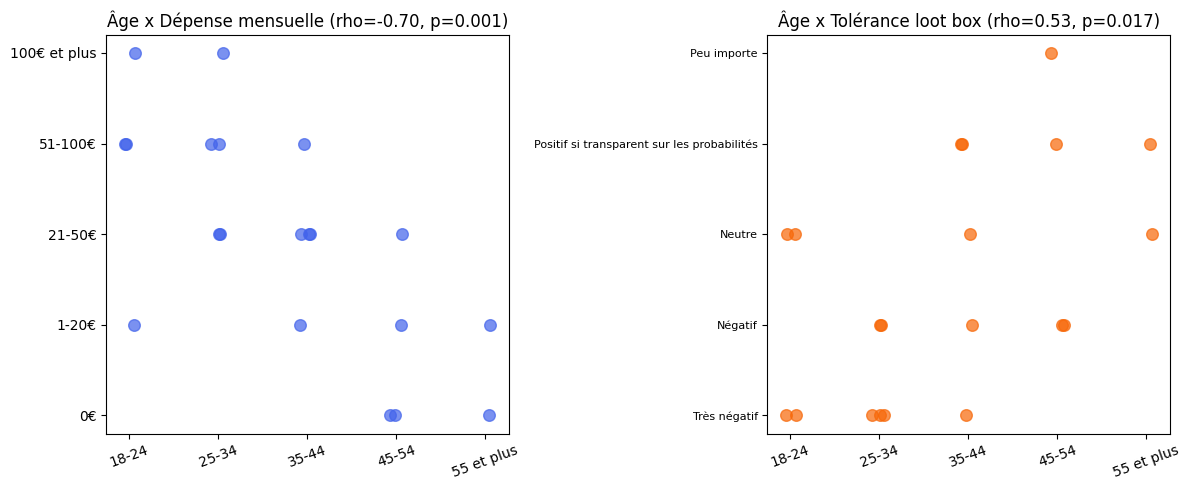

In [8]:
age_order = {'18-24':1,'25-34':2,'35-44':3,'45-54':4,'55 et plus':5}
depense_order = {'0€':0,'1-20€':1,'21-50€':2,'51-100€':3,'100€ et plus':4}
lootbox_order = {'Très négatif':1,'Négatif':2,'Neutre':3,
                  'Positif si transparent sur les probabilités':4,'Peu importe':5}
survey['age_rank'] = survey['age'].map(age_order)
survey['depense_rank'] = survey['depenses'].map(depense_order)
survey['lootbox_rank'] = survey['lootbox'].map(lootbox_order)

r_spend, p_spend = spearmanr(survey['age_rank'], survey['depense_rank'])
r_loot, p_loot = spearmanr(survey['age_rank'], survey['lootbox_rank'])
print(f'Âge x Dépense mensuelle  : rho={r_spend:.2f}, p={p_spend:.3f}')
print(f'Âge x Tolérance loot box : rho={r_loot:.2f}, p={p_loot:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12,5))
jitter = np.random.default_rng(0).uniform(-0.08, 0.08, len(survey))
axes[0].scatter(survey['age_rank']+jitter, survey['depense_rank'], color='#4263EB', s=70, alpha=0.7)
axes[0].set_xticks(range(1,6)); axes[0].set_xticklabels(age_order.keys(), rotation=20)
axes[0].set_yticks(range(0,5)); axes[0].set_yticklabels(depense_order.keys())
axes[0].set_title(f'Âge x Dépense mensuelle (rho={r_spend:.2f}, p={p_spend:.3f})')
axes[1].scatter(survey['age_rank']+jitter, survey['lootbox_rank'], color='#F76707', s=70, alpha=0.7)
axes[1].set_xticks(range(1,6)); axes[1].set_xticklabels(age_order.keys(), rotation=20)
axes[1].set_yticks(range(1,6)); axes[1].set_yticklabels(lootbox_order.keys(), fontsize=8)
axes[1].set_title(f'Âge x Tolérance loot box (rho={r_loot:.2f}, p={p_loot:.3f})')
plt.tight_layout()
plt.show()


**Les deux seules corrélations statistiquement significatives (p<0,05) de l'enquête racontent une histoire cohérente :**
- Plus un joueur est jeune, plus il dépense (rho=-0,70, **p=0,001**)
- Mais plus un joueur est jeune, plus il rejette les achats aléatoires payants — les "loot box" (rho=0,53, **p=0,017**)

→ Le segment le plus rentable en valeur directe (18-34 ans) est aussi le plus intransigeant sur la monétisation agressive : un modèle économique basé sur des loot box serait donc le pire choix pour capter précisément ce public.

*(Détail complet des tests : `P10_Phase4_Correlations_Questionnaire.ipynb`)*


---
## 6. Recommandation finale

**Segment retenu : Action/RPG, cœur de cible 18-34 ans** — ventes historiques, engagement du catalogue et dépense déclarée convergent tous vers ce choix, avec deux garde-fous imposés par les données : un modèle économique **premium et transparent** (aucune loot box) et un **mode coopératif accessible** en option pour élargir vers un public plus familial.

**Concept recommandé — "ECHOES" *(titre de travail)*** : un Action-RPG coopératif de science-fiction, jusqu'à 4 joueurs, où chaque personnage a une histoire différente et où les choix des joueurs font évoluer un monde partagé. Ce concept reprend directement les deux premiers facteurs déclarés pour essayer un nouveau Triple A (univers/histoire originale, puis multijoueur entre amis) et plusieurs suggestions spontanées du questionnaire.

**Écosystème :** PC + PlayStation 5 dès le lancement, Xbox en day-and-date (moteur cross-plateforme), Switch/cloud différés de 6-12 mois ; modèle premium + DLC narratifs post-lancement ; démo coopérative en amont ; doublage multilingue assisté par IA.


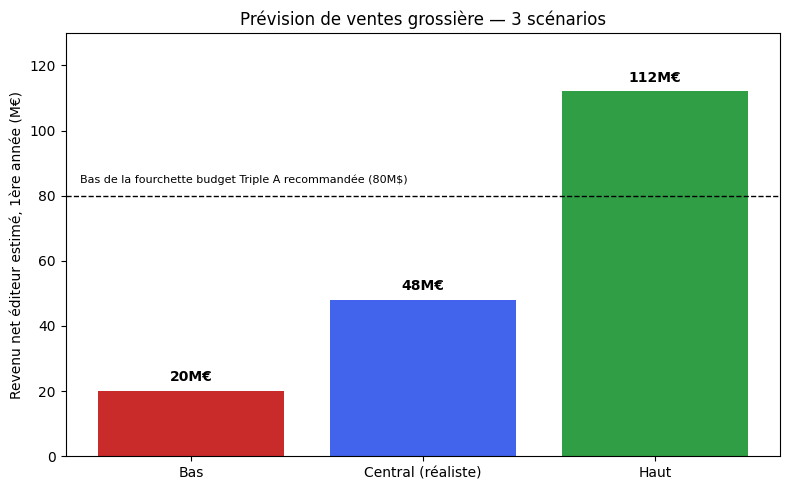

In [9]:
scenarios = pd.DataFrame({
    'Scénario': ['Bas', 'Central (réaliste)', 'Haut'],
    "Ventes (M unités, 1ère année)": [0.5, 1.2, 2.8],
})
scenarios['Revenu net estimé (M€)'] = (scenarios["Ventes (M unités, 1ère année)"] * 40).round(0)

fig, ax = plt.subplots(figsize=(8,5))
colors_bar = ['#C92A2A', '#4263EB', '#2F9E44']
bars = ax.bar(scenarios['Scénario'], scenarios['Revenu net estimé (M€)'], color=colors_bar)
ax.set_ylabel('Revenu net éditeur estimé, 1ère année (M€)')
ax.set_title('Prévision de ventes grossière — 3 scénarios')
ax.set_ylim(0, 130)
ax.axhline(80, color='black', linestyle='--', linewidth=1)
ax.text(0.02, 84, 'Bas de la fourchette budget Triple A recommandée (80M$)',
        fontsize=8, ha='left', transform=ax.get_yaxis_transform())
for bar, val in zip(bars, scenarios['Revenu net estimé (M€)']):
    ax.text(bar.get_x()+bar.get_width()/2, val+3, f'{val:.0f}M€', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


**Lecture :** le scénario central (~1,2M unités, ~48M€ net la première année) ne couvre pas à lui seul le bas de la fourchette budgétaire Triple A. C'est cohérent avec la réalité du secteur : un premier titre Triple A se finance rarement sur sa seule première année — le plan de financement doit intégrer les ventes en Year 2+, les DLC narratifs et les portages différés.

*(Détail complet, y compris les 3 réponses préparées aux questions probables de soutenance : `P10_Phase5_Recommandation_Finale.ipynb`)*

---

## Notebooks détaillés

| Phase | Notebook |
|---|---|
| 1 — Nettoyage des données | `P10_Phase1_Nettoyage.ipynb` |
| 2 — Tendances, SWOT, PESTEL | `P10_Phase2_Tendances_SWOT_PESTEL.ipynb` |
| 3 — Segmentation & questionnaire | `P10_Phase3_Segmentation_Questionnaire.ipynb` |
| 4 — Corrélations questionnaire | `P10_Phase4_Correlations_Questionnaire.ipynb` |
| 5 — Recommandation finale | `P10_Phase5_Recommandation_Finale.ipynb` |

*Projet réalisé par Aurélie Dupassieux — Data ESN.*
